In [1]:
import os
# from google.colab import drive
# drive.mount('/content/drive')

# %cd /content/drive/MyDrive/Files/COMP545_PROJECT

In [2]:
import json
import os
from pathlib import Path
import pandas as pd
import numpy as np

Model Cost

In [3]:
model_info_file_path = './data/model_data/models_info.json'
model_info = pd.read_json(model_info_file_path).T

In [4]:
cost_for_each_model = model_info['co2_cost']
cost_for_each_model

MaziyarPanahi/calme-3.2-instruct-78b        66.01
Qwen/Qwen2.5-0.5B-Instruct                   1.24
Qwen/Qwen2.5-1.5B-Instruct                   1.37
Qwen/Qwen2.5-14B-Instruct                    3.55
Qwen/Qwen2.5-32B-Instruct                    11.5
Qwen/Qwen2.5-3B-Instruct                     2.78
Qwen/Qwen2.5-72B-Instruct                   47.65
Qwen/Qwen2.5-7B-Instruct                     3.24
deepseek-ai/DeepSeek-R1-Distill-Qwen-14B     3.99
deepseek-ai/DeepSeek-R1-Distill-Qwen-32B    47.28
deepseek-ai/DeepSeek-R1-Distill-Qwen-7B      1.37
meta-llama/Llama-3.1-70B-Instruct           40.22
meta-llama/Llama-3.1-8B-Instruct             2.11
meta-llama/Llama-3.2-1B-Instruct             0.81
meta-llama/Llama-3.2-3B-Instruct             1.93
meta-llama/Llama-3.3-70B-Instruct           76.56
Name: co2_cost, dtype: object

Extracted dataset OOD

In [5]:
extracted_data_file_path = './data/model_data/extracted_dataset_samples_ood.jsonl'
extracted_data = pd.read_json(extracted_data_file_path, lines=True)
extracted_data


,query,answer,model,dataset,subset,correct,query_id
0,"A large gene has dozens of exons, of which the...",(D),MaziyarPanahi/calme-3.2-instruct-78b,gpqa,main,1,gpqa_q0
1,"A large gene has dozens of exons, of which the...",(B),MaziyarPanahi/calme-3.2-instruct-78b,gpqa,extended,1,gpqa_q0
2,"A large gene has dozens of exons, of which the...",(D),Qwen/Qwen2.5-32B-Instruct,gpqa,main,0,gpqa_q0
3,"A large gene has dozens of exons, of which the...",(D),Qwen/Qwen2.5-32B-Instruct,gpqa,extended,0,gpqa_q0
4,"A large gene has dozens of exons, of which the...",(D),Qwen/Qwen2.5-72B-Instruct,gpqa,main,0,gpqa_q0
...,...,...,...,...,...,...,...
31163,"In the dynamic realm of technology, a prestigi...","Software Development: Alice, Project Managemen...",meta-llama/Llama-3.2-3B-Instruct,musr,team_allocation,0,musr_q755
31164,"In the dynamic realm of technology, a prestigi...","Software Development: Alice, Project Managemen...",meta-llama/Llama-3.2-1B-Instruct,musr,team_allocation,0,musr_q755
31165,"In the dynamic realm of technology, a prestigi...","Software Development: Alice, Project Managemen...",deepseek-ai/DeepSeek-R1-Distill-Qwen-14B,musr,team_allocation,1,musr_q755
31166,"In the dynamic realm of technology, a prestigi...","Software Development: Alice, Project Managemen...",deepseek-ai/DeepSeek-R1-Distill-Qwen-32B,musr,team_allocation,1,musr_q755


Notice, it the query may existed in both main and subset, and the output may different, we need to collect them all to determine whether they are acutally right

In [6]:
unique_extracted_data = extracted_data.groupby(['query_id','model'])['correct'].mean().reset_index()
unique_extracted_data

,query_id,model,correct
0,gpqa_q0,MaziyarPanahi/calme-3.2-instruct-78b,1.0
1,gpqa_q0,Qwen/Qwen2.5-0.5B-Instruct,0.5
2,gpqa_q0,Qwen/Qwen2.5-1.5B-Instruct,0.0
3,gpqa_q0,Qwen/Qwen2.5-14B-Instruct,0.0
4,gpqa_q0,Qwen/Qwen2.5-32B-Instruct,0.0
...,...,...,...
20811,musr_q99,meta-llama/Llama-3.1-70B-Instruct,1.0
20812,musr_q99,meta-llama/Llama-3.1-8B-Instruct,1.0
20813,musr_q99,meta-llama/Llama-3.2-1B-Instruct,1.0
20814,musr_q99,meta-llama/Llama-3.2-3B-Instruct,1.0


Read Model csv

In [7]:
# ID数据的路由分数
seen_model_score_ID_df = pd.read_csv('all_alpha_model_ID_seen.csv')
unseen_model_score_ID_df = pd.read_csv('all_alpha_model_ID_unseen.csv')

# OOD数据的路由分数
seen_model_score_OOD_df = pd.read_csv('all_alpha_model_OOD_seen.csv')
unseen_model_score_OOD_df = pd.read_csv('all_alpha_model_OOD_unseen.csv')

print(f"ID seen: {len(seen_model_score_ID_df)}, ID unseen: {len(unseen_model_score_ID_df)}")
print(f"OOD seen: {len(seen_model_score_OOD_df)}, OOD unseen: {len(unseen_model_score_OOD_df)}")

ID seen: 1870500, ID unseen: 1870500
OOD seen: 130100, OOD unseen: 130100


In [8]:
def select_from_alpha(model_score_df,alpha):
    sel = model_score_df['alpha']==alpha
    selected_df = model_score_df[sel].copy()

    return selected_df[["query_id","best_model","score","alpha"]]


In [9]:
def eval_selection(model_score_df,extracted_data,cost_map,alpha):
    unique_extracted_data = extracted_data.groupby(['query_id','model'])['correct'].mean().reset_index()
    selection_df = select_from_alpha(model_score_df,alpha)
    merged_df = pd.merge(selection_df, unique_extracted_data, left_on=['query_id','best_model'], right_on=['query_id','model'], how='left')
    mena_acc = merged_df['correct'].mean()

    mean_cost = merged_df['best_model'].map(cost_map).mean()
    return mena_acc, mean_cost


In [10]:
print("OOD + seen:", eval_selection(seen_model_score_OOD_df, extracted_data, cost_for_each_model, 0.01))
print("OOD + unseen:", eval_selection(unseen_model_score_OOD_df, extracted_data, cost_for_each_model, 0.01))

OOD + seen: (np.float64(0.5175762234178837), np.float64(65.67393543428061))
OOD + unseen: (np.float64(0.40371509095567515), np.float64(43.41700999231445))


Evaluation For OOD

In [11]:

def plot_acc_cost_curve(model_score_df,extracted_data,cost_map):
    accs = []
    costs = []
    alphas = sorted(model_score_df['alpha'].unique())

    for alpha in alphas:
        mena_acc, mean_cost = eval_selection(model_score_df,extracted_data,cost_map,alpha)
        accs.append(mena_acc)
        costs.append(mean_cost)
    return alphas, accs, costs





PLOT (EVAL for OOD Data)

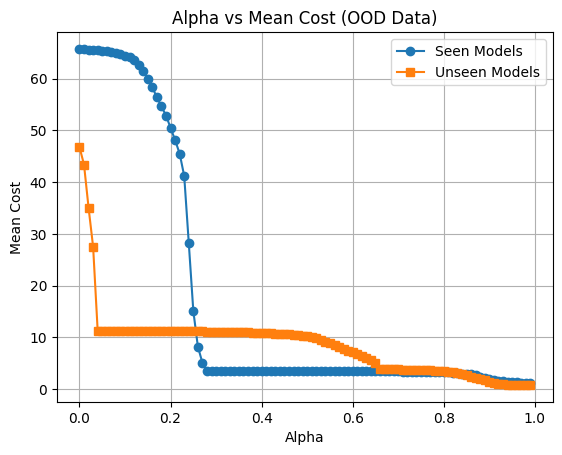

In [12]:
alphas_OOD_seen, accs_OOD_seen, costs_OOD_seen = plot_acc_cost_curve(seen_model_score_OOD_df, extracted_data, cost_for_each_model)
alphas_OOD_unseen, accs_OOD_unseen, costs_OOD_unseen = plot_acc_cost_curve(unseen_model_score_OOD_df, extracted_data, cost_for_each_model)

import matplotlib.pyplot as plt
plt.plot(alphas_OOD_seen, costs_OOD_seen, marker='o', label='Seen Models')
plt.plot(alphas_OOD_unseen, costs_OOD_unseen, marker='s', label='Unseen Models')
plt.xlabel('Alpha')
plt.ylabel('Mean Cost')
plt.title('Alpha vs Mean Cost (OOD Data)')
plt.legend()
plt.grid()
plt.show()

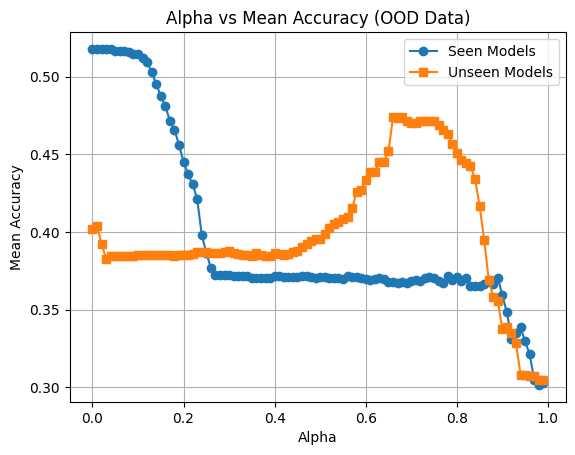

In [13]:
plt.plot(alphas_OOD_seen, accs_OOD_seen, marker='o', label='Seen Models')
plt.plot(alphas_OOD_unseen, accs_OOD_unseen, marker='s', label='Unseen Models')
plt.xlabel('Alpha')
plt.ylabel('Mean Accuracy')
plt.title('Alpha vs Mean Accuracy (OOD Data)')
plt.legend()
plt.grid()
plt.show()

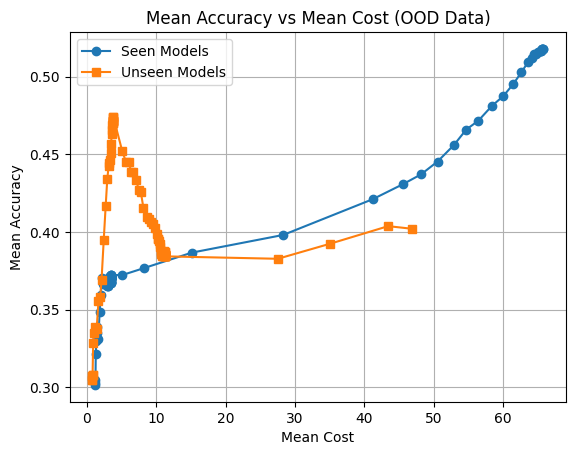

In [14]:
plt.plot(costs_OOD_seen, accs_OOD_seen, marker='o', label='Seen Models')
plt.plot(costs_OOD_unseen, accs_OOD_unseen, marker='s', label='Unseen Models')
plt.xlabel('Mean Cost')
plt.ylabel('Mean Accuracy')
plt.title('Mean Accuracy vs Mean Cost (OOD Data)')
plt.legend()
plt.grid()
plt.show()

In [15]:
acc_df_OOD_seen = pd.DataFrame({'alpha': alphas_OOD_seen, 'mean_accuracy': accs_OOD_seen, 'mean_cost': costs_OOD_seen})
acc_df_OOD_unseen = pd.DataFrame({'alpha': alphas_OOD_unseen, 'mean_accuracy': accs_OOD_unseen, 'mean_cost': costs_OOD_unseen})
print("OOD Seen Models:")
display(acc_df_OOD_seen)
print("\nOOD Unseen Models:")
display(acc_df_OOD_unseen)

OOD Seen Models:


,alpha,mean_accuracy,mean_cost
0,0.00,0.517576,65.769954
1,0.01,0.517576,65.673935
2,0.02,0.517576,65.625926
3,0.03,0.517576,65.625926
4,0.04,0.517832,65.577917
...,...,...,...
95,0.95,0.329516,1.366649
96,0.96,0.321214,1.286380
97,0.97,0.304561,1.247571
98,0.98,0.301486,1.240999



OOD Unseen Models:


,alpha,mean_accuracy,mean_cost
0,0.00,0.402050,46.813751
1,0.01,0.403715,43.417010
2,0.02,0.392442,35.074412
3,0.03,0.382706,27.516533
4,0.04,0.384269,11.316026
...,...,...,...
95,0.95,0.308045,0.818609
96,0.96,0.307405,0.813874
97,0.97,0.307405,0.812583
98,0.98,0.304714,0.810000


ID ALpha data

In [16]:
# ID scores 已在上方加载
print("ID Seen Models scores:")
display(seen_model_score_ID_df.head())
print("\nID Unseen Models scores:")
display(unseen_model_score_ID_df.head())

ID Seen Models scores:


,query_id,best_model,score,alpha
0,bbh_q0,MaziyarPanahi/calme-3.2-instruct-78b,0.986781,0.0
1,bbh_q1,MaziyarPanahi/calme-3.2-instruct-78b,0.929453,0.0
2,bbh_q2,MaziyarPanahi/calme-3.2-instruct-78b,0.942280,0.0
3,bbh_q3,MaziyarPanahi/calme-3.2-instruct-78b,0.978345,0.0
4,bbh_q4,MaziyarPanahi/calme-3.2-instruct-78b,0.961111,0.0



ID Unseen Models scores:


,query_id,best_model,score,alpha
0,bbh_q0,Qwen/Qwen2.5-72B-Instruct,0.982541,0.0
1,bbh_q1,Qwen/Qwen2.5-72B-Instruct,0.902933,0.0
2,bbh_q2,Qwen/Qwen2.5-72B-Instruct,0.918361,0.0
3,bbh_q3,Qwen/Qwen2.5-72B-Instruct,0.971209,0.0
4,bbh_q4,Qwen/Qwen2.5-72B-Instruct,0.946834,0.0


Extracted Dataset ID

In [17]:
extracted_data_ID_file_path = './data/model_data/extracted_dataset_samples.jsonl'
extracted_data_ID = pd.read_json(extracted_data_ID_file_path, lines=True)
extracted_data_ID

,query,answer,model,dataset,subset,correct,query_id
0,not ( True ) and ( True ) is,False,MaziyarPanahi/calme-3.2-instruct-78b,bbh,boolean_expressions,1,bbh_q0
1,not ( True ) and ( True ) is,False,Qwen/Qwen2.5-32B-Instruct,bbh,boolean_expressions,1,bbh_q0
2,not ( True ) and ( True ) is,False,Qwen/Qwen2.5-72B-Instruct,bbh,boolean_expressions,1,bbh_q0
3,not ( True ) and ( True ) is,False,Qwen/Qwen2.5-14B-Instruct,bbh,boolean_expressions,1,bbh_q0
4,not ( True ) and ( True ) is,False,Qwen/Qwen2.5-7B-Instruct,bbh,boolean_expressions,1,bbh_q0
...,...,...,...,...,...,...,...
305867,The frequency range of a commercially broadcas...,F,deepseek-ai/DeepSeek-R1-Distill-Qwen-14B,mmlu_pro,None,0,mmlu_pro_q11642
305868,The frequency range of a commercially broadcas...,F,deepseek-ai/DeepSeek-R1-Distill-Qwen-32B,mmlu_pro,None,0,mmlu_pro_q11642
305869,The frequency range of a commercially broadcas...,F,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,mmlu_pro,None,0,mmlu_pro_q11642
305870,Suppose there are 100 identical firms in a per...,A,meta-llama/Llama-3.1-70B-Instruct,mmlu_pro,None,0,mmlu_pro_q11643


In [18]:
alphas_ID_seen, accs_ID_seen, costs_ID_seen = plot_acc_cost_curve(seen_model_score_ID_df, extracted_data_ID, cost_for_each_model)
alphas_ID_unseen, accs_ID_unseen, costs_ID_unseen = plot_acc_cost_curve(unseen_model_score_ID_df, extracted_data_ID, cost_for_each_model)

PLOT (EVAL ID data)

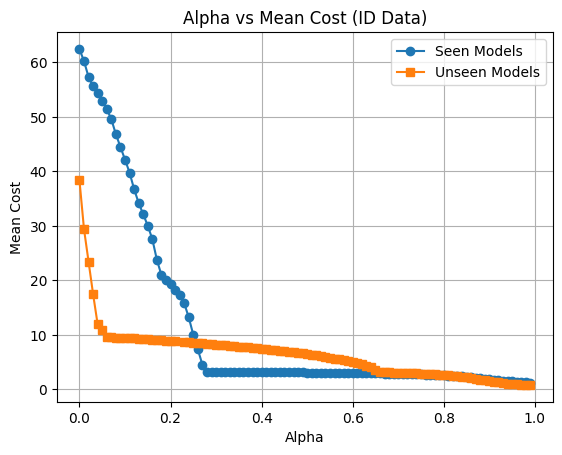

In [19]:
import matplotlib.pyplot as plt
plt.plot(alphas_ID_seen, costs_ID_seen, marker='o', label='Seen Models')
plt.plot(alphas_ID_unseen, costs_ID_unseen, marker='s', label='Unseen Models')
plt.xlabel('Alpha')
plt.ylabel('Mean Cost')
plt.title('Alpha vs Mean Cost (ID Data)')
plt.legend()
plt.grid()
plt.show()

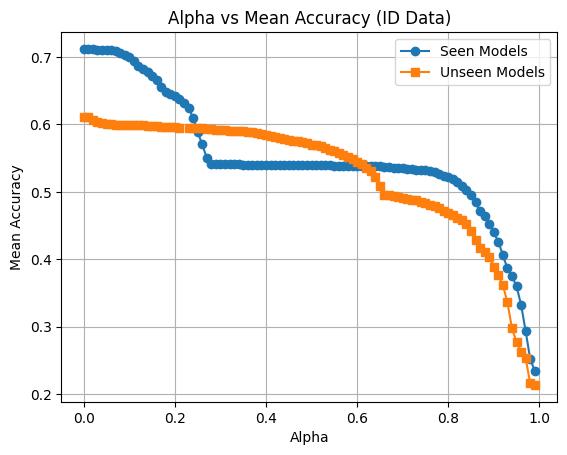

In [20]:
plt.plot(alphas_ID_seen, accs_ID_seen, marker='o', label='Seen Models')
plt.plot(alphas_ID_unseen, accs_ID_unseen, marker='s', label='Unseen Models')
plt.xlabel('Alpha')
plt.ylabel('Mean Accuracy')
plt.title('Alpha vs Mean Accuracy (ID Data)')
plt.legend()
plt.grid()
plt.show()

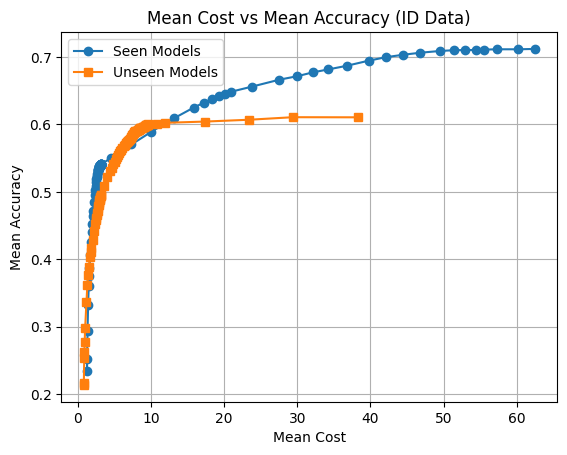

In [21]:
plt.plot(costs_ID_seen, accs_ID_seen, marker='o', label='Seen Models')
plt.plot(costs_ID_unseen, accs_ID_unseen, marker='s', label='Unseen Models')
plt.xlabel('Mean Cost')
plt.ylabel('Mean Accuracy')
plt.title('Mean Cost vs Mean Accuracy (ID Data)')
plt.legend()
plt.grid()
plt.show()

In [22]:
acc_df_ID_seen = pd.DataFrame({'alpha': alphas_ID_seen, 'mean_accuracy': accs_ID_seen, 'mean_cost': costs_ID_seen})
acc_df_ID_unseen = pd.DataFrame({'alpha': alphas_ID_unseen, 'mean_accuracy': accs_ID_unseen, 'mean_cost': costs_ID_unseen})
print("ID Seen Models:")
display(acc_df_ID_seen)
print("\nID Unseen Models:")
display(acc_df_ID_unseen)

ID Seen Models:


,alpha,mean_accuracy,mean_cost
0,0.00,0.712023,62.470119
1,0.01,0.711471,60.210614
2,0.02,0.711497,57.333227
3,0.03,0.711001,55.582645
4,0.04,0.710466,54.370853
...,...,...,...
95,0.95,0.360137,1.478719
96,0.96,0.332802,1.397371
97,0.97,0.293703,1.319139
98,0.98,0.252332,1.259696



ID Unseen Models:


,alpha,mean_accuracy,mean_cost
0,0.00,0.610585,38.365427
1,0.01,0.610751,29.398439
2,0.02,0.607008,23.434677
3,0.03,0.604308,17.444038
4,0.04,0.602410,11.918439
...,...,...,...
95,0.95,0.277628,0.925553
96,0.96,0.263209,0.888948
97,0.97,0.253513,0.865955
98,0.98,0.216262,0.813024


In [23]:
acc_df_ID_seen[acc_df_ID_seen["mean_accuracy"].between(0.5, 0.6)]

,alpha,mean_accuracy,mean_cost
25,0.25,0.588766,9.987230
26,0.26,0.570292,7.319383
27,0.27,0.550160,4.500884
28,0.28,0.540937,3.186427
29,0.29,0.540937,3.182569
30,0.30,0.540990,3.178763
31,0.31,0.540883,3.174503
32,0.32,0.540883,3.170509
33,0.33,0.540990,3.166135
34,0.34,0.540937,3.162167


Save accuracy cost dataframe

In [24]:
acc_df_ID_seen.to_csv('accuracy_cost_curve_ID_seen.csv', index=False)
acc_df_ID_unseen.to_csv('accuracy_cost_curve_ID_unseen.csv', index=False)
acc_df_OOD_seen.to_csv('accuracy_cost_curve_OOD_seen.csv', index=False)
acc_df_OOD_unseen.to_csv('accuracy_cost_curve_OOD_unseen.csv', index=False)
print("Saved all accuracy-cost curves.")

Saved all accuracy-cost curves.


Compare to Baseline

BERT

In [25]:
baseline_scores_bert = pd.read_json('./data/baseline_scores/bert_router_scores_id.jsonl', lines=True)
baseline_scores_bert

,query_id,dataset,subset,query,router,score
0,bbh_q0,bbh,boolean_expressions,not ( True ) and ( True ) is,bert,0.394552
1,bbh_q1,bbh,boolean_expressions,not True or False or ( False ) is,bert,0.420922
2,bbh_q2,bbh,boolean_expressions,True or not False and True and False is,bert,0.432683
3,bbh_q3,bbh,boolean_expressions,not True and ( False or True ) is,bert,0.408421
4,bbh_q4,bbh,boolean_expressions,not True or ( False and True ) is,bert,0.408717
...,...,...,...,...,...,...
18700,mmlu_pro_q11640,mmlu_pro,None,A hot mild steel rod is placed in a carbonaceo...,bert,0.468887
18701,mmlu_pro_q11641,mmlu_pro,None,Consider the evaporation of liquid ammonia int...,bert,0.464472
18702,mmlu_pro_q11642,mmlu_pro,None,The frequency range of a commercially broadcas...,bert,0.467289
18703,mmlu_pro_q11643,mmlu_pro,None,Suppose there are 100 identical firms in a per...,bert,0.446196


In [26]:
extracted_data_ID

,query,answer,model,dataset,subset,correct,query_id
0,not ( True ) and ( True ) is,False,MaziyarPanahi/calme-3.2-instruct-78b,bbh,boolean_expressions,1,bbh_q0
1,not ( True ) and ( True ) is,False,Qwen/Qwen2.5-32B-Instruct,bbh,boolean_expressions,1,bbh_q0
2,not ( True ) and ( True ) is,False,Qwen/Qwen2.5-72B-Instruct,bbh,boolean_expressions,1,bbh_q0
3,not ( True ) and ( True ) is,False,Qwen/Qwen2.5-14B-Instruct,bbh,boolean_expressions,1,bbh_q0
4,not ( True ) and ( True ) is,False,Qwen/Qwen2.5-7B-Instruct,bbh,boolean_expressions,1,bbh_q0
...,...,...,...,...,...,...,...
305867,The frequency range of a commercially broadcas...,F,deepseek-ai/DeepSeek-R1-Distill-Qwen-14B,mmlu_pro,None,0,mmlu_pro_q11642
305868,The frequency range of a commercially broadcas...,F,deepseek-ai/DeepSeek-R1-Distill-Qwen-32B,mmlu_pro,None,0,mmlu_pro_q11642
305869,The frequency range of a commercially broadcas...,F,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,mmlu_pro,None,0,mmlu_pro_q11642
305870,Suppose there are 100 identical firms in a per...,A,meta-llama/Llama-3.1-70B-Instruct,mmlu_pro,None,0,mmlu_pro_q11643


In [50]:
# slm = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
# llm = "MaziyarPanahi/calme-3.2-instruct-78b"

slm = "Qwen/Qwen2.5-7B-Instruct"
llm = "Qwen/Qwen2.5-72B-Instruct"

In [51]:
pct = np.arange(0, 101, 5)
thresholds = np.percentile(baseline_scores_bert["score"].to_numpy(), pct)

In [52]:
correct_raw = (extracted_data_ID.loc[extracted_data_ID['model'].isin([slm, llm]),["query_id","model","correct"]]# select only SLM and LLM
                 .drop_duplicates(["query_id","model"]) # remove duplicates
                 .pivot(index="query_id", columns="model", values="correct")# pivot table
                 .reindex(columns=[slm, llm]))
has_table = correct_raw.notna().astype(int)
correct_table = correct_raw.fillna(0)
correct_table

model,Qwen/Qwen2.5-7B-Instruct,Qwen/Qwen2.5-72B-Instruct
query_id,,
bbh_q0,1,1
bbh_q1,0,1
bbh_q10,1,1
bbh_q100,1,1
bbh_q1000,1,1
...,...,...
mmlu_pro_q9995,1,0
mmlu_pro_q9996,0,0
mmlu_pro_q9997,0,1


In [53]:
baseline_Bert_df = (baseline_scores_bert[["query_id","score"]]
    .merge(correct_table,left_on ="query_id",right_index=True,how="left")
    .merge(has_table.add_prefix("has_"),left_on ="query_id",right_index=True,how="left")
    .fillna(0))
baseline_Bert_df

,query_id,score,Qwen/Qwen2.5-7B-Instruct,Qwen/Qwen2.5-72B-Instruct,has_Qwen/Qwen2.5-7B-Instruct,has_Qwen/Qwen2.5-72B-Instruct
0,bbh_q0,0.394552,1.0,1.0,1.0,1.0
1,bbh_q1,0.420922,0.0,1.0,1.0,1.0
2,bbh_q2,0.432683,1.0,1.0,1.0,1.0
3,bbh_q3,0.408421,1.0,1.0,1.0,1.0
4,bbh_q4,0.408717,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...
18700,mmlu_pro_q11640,0.468887,0.0,0.0,1.0,1.0
18701,mmlu_pro_q11641,0.464472,1.0,1.0,1.0,1.0
18702,mmlu_pro_q11642,0.467289,0.0,0.0,1.0,1.0
18703,mmlu_pro_q11643,0.446196,0.0,0.0,0.0,0.0


Convert baseline_Bert_df column to numpy

In [54]:
scores_bert=baseline_Bert_df["score"].to_numpy()
slm_column = baseline_Bert_df[slm].to_numpy()
llm_column = baseline_Bert_df[llm].to_numpy()

In [55]:
has_slm_column = baseline_Bert_df["has_"+slm].to_numpy()
has_llm_column = baseline_Bert_df["has_"+llm].to_numpy()

Their cost

In [56]:
cost_slm = cost_for_each_model[slm]
cost_llm = cost_for_each_model[llm]

In [57]:
mean_accuracy_Bert_baseline = []
mean_cost_Bert_baseline = []

In [58]:
for t in thresholds:
    use_slm = scores_bert>t
    acc_vec = np.where(use_slm, has_slm_column*slm_column, has_llm_column*llm_column)#if not find, do not  add
    mean_accuracy_Bert_baseline.append(acc_vec.mean())

    cost_vec = np.where(use_slm, cost_slm*has_slm_column, cost_llm*has_llm_column)#if not find, do not add
    mean_cost_Bert_baseline.append(cost_vec.mean())

MF

In [59]:
baseline_scores_mf = pd.read_json('./data/baseline_scores/mf_router_scores_id.jsonl', lines=True)
baseline_scores_mf

,query_id,dataset,subset,query,router,score
0,bbh_q0,bbh,boolean_expressions,not ( True ) and ( True ) is,mf,0.828239
1,bbh_q1,bbh,boolean_expressions,not True or False or ( False ) is,mf,0.806490
2,bbh_q2,bbh,boolean_expressions,True or not False and True and False is,mf,0.803951
3,bbh_q3,bbh,boolean_expressions,not True and ( False or True ) is,mf,0.809753
4,bbh_q4,bbh,boolean_expressions,not True or ( False and True ) is,mf,0.814088
...,...,...,...,...,...,...
18700,mmlu_pro_q11640,mmlu_pro,None,A hot mild steel rod is placed in a carbonaceo...,mf,0.687482
18701,mmlu_pro_q11641,mmlu_pro,None,Consider the evaporation of liquid ammonia int...,mf,0.636182
18702,mmlu_pro_q11642,mmlu_pro,None,The frequency range of a commercially broadcas...,mf,0.611274
18703,mmlu_pro_q11643,mmlu_pro,None,Suppose there are 100 identical firms in a per...,mf,0.770183


In [60]:
pct = np.arange(0, 101, 5)
MF_thresholds = np.percentile(baseline_scores_mf["score"].to_numpy(), pct)

In [61]:
baseline_MF_df = (baseline_scores_mf[["query_id","score"]]
    .merge(correct_table,left_on ="query_id",right_index=True,how="left")
    .merge(has_table.add_prefix("has_"),left_on ="query_id",right_index=True,how="left")
    .fillna(0))
baseline_MF_df

,query_id,score,Qwen/Qwen2.5-7B-Instruct,Qwen/Qwen2.5-72B-Instruct,has_Qwen/Qwen2.5-7B-Instruct,has_Qwen/Qwen2.5-72B-Instruct
0,bbh_q0,0.828239,1.0,1.0,1.0,1.0
1,bbh_q1,0.806490,0.0,1.0,1.0,1.0
2,bbh_q2,0.803951,1.0,1.0,1.0,1.0
3,bbh_q3,0.809753,1.0,1.0,1.0,1.0
4,bbh_q4,0.814088,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...
18700,mmlu_pro_q11640,0.687482,0.0,0.0,1.0,1.0
18701,mmlu_pro_q11641,0.636182,1.0,1.0,1.0,1.0
18702,mmlu_pro_q11642,0.611274,0.0,0.0,1.0,1.0
18703,mmlu_pro_q11643,0.770183,0.0,0.0,0.0,0.0


Convert baseline_MF_df column to numpy

In [62]:
scores_MF=baseline_MF_df["score"].to_numpy()
slm_column = baseline_MF_df[slm].to_numpy()
llm_column = baseline_MF_df[llm].to_numpy()

In [63]:
has_slm_column = baseline_MF_df["has_"+slm].to_numpy()
has_llm_column = baseline_MF_df["has_"+llm].to_numpy()

COST

In [64]:
cost_slm = cost_for_each_model[slm]
cost_llm = cost_for_each_model[llm]

In [65]:
mean_accuracy_MF_baseline = []
mean_cost_MF_baseline = []

In [66]:
for t in MF_thresholds:
    use_slm = scores_MF>t
    acc_vec = np.where(use_slm, has_slm_column*slm_column, has_llm_column*llm_column)#if not find, do not  add
    mean_accuracy_MF_baseline.append(acc_vec.mean())

    cost_vec = np.where(use_slm, cost_slm*has_slm_column, cost_llm*has_llm_column)#if not find, do not add
    mean_cost_MF_baseline.append(cost_vec.mean())

PLOT TO ID graph

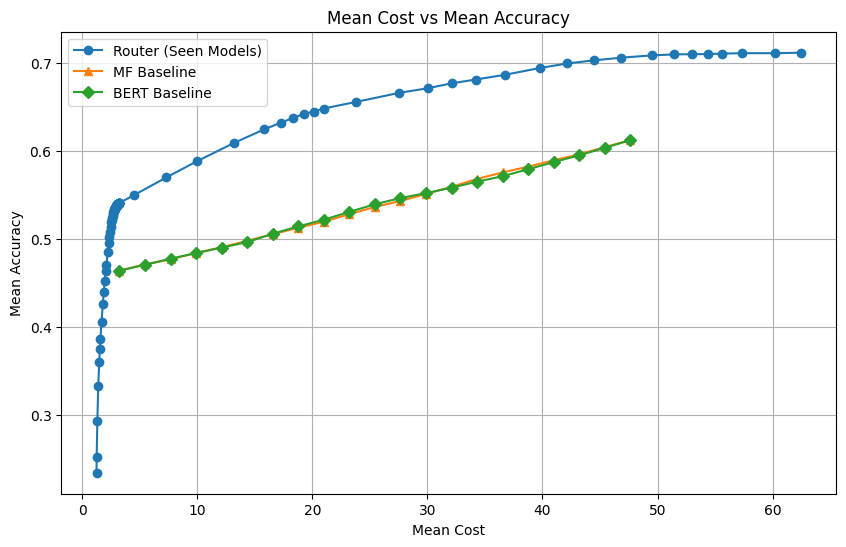

[np.float64(3.2418545843357407), np.float64(5.461761026463513), np.float64(7.681667468591287), np.float64(9.901573910719058), np.float64(12.121480352846833), np.float64(14.343761026463511), np.float64(16.563667468591287), np.float64(18.778825447741248), np.float64(20.99873188986902), np.float64(23.21863833199679), np.float64(25.440919005613466), np.float64(27.660825447741242), np.float64(29.88073188986902), np.float64(32.100638331996784), np.float64(34.318170542635656), np.float64(36.540451216252336), np.float64(38.7603576583801), np.float64(40.98026410050788), np.float64(43.20017054263565), np.float64(45.42007698476342), np.float64(47.6423576583801)]
[np.float64(0.46431435445068164), np.float64(0.47094359796845764), np.float64(0.47794707297514033), np.float64(0.4843090082865544), np.float64(0.4905105586741513), np.float64(0.4967121090617482), np.float64(0.5063352044907778), np.float64(0.5146217588879979), np.float64(0.5222133119486768), np.float64(0.5311414060411654), np.float64(0.539

In [67]:
plt.figure(figsize=(10, 6))
plt.plot(costs_ID_seen, accs_ID_seen, marker='o', label="Router (Seen Models)")
# plt.plot(costs_ID_unseen, accs_ID_unseen, marker='s', label="Router (Unseen Models)")
plt.plot(mean_cost_MF_baseline, mean_accuracy_MF_baseline, marker='^', label='MF Baseline')
plt.plot(mean_cost_Bert_baseline, mean_accuracy_Bert_baseline, marker='D', label='BERT Baseline')
plt.legend()
plt.xlabel('Mean Cost')
plt.ylabel('Mean Accuracy')
plt.title('Mean Cost vs Mean Accuracy')
plt.grid()
plt.savefig('mean_cost_vs_mean_accuracy_comparison_seen.png', dpi=300, bbox_inches='tight')
plt.show()

# print(mean_cost_MF_baseline)
# print(mean_accuracy_MF_baseline)

print(mean_cost_Bert_baseline)
print(mean_accuracy_Bert_baseline)

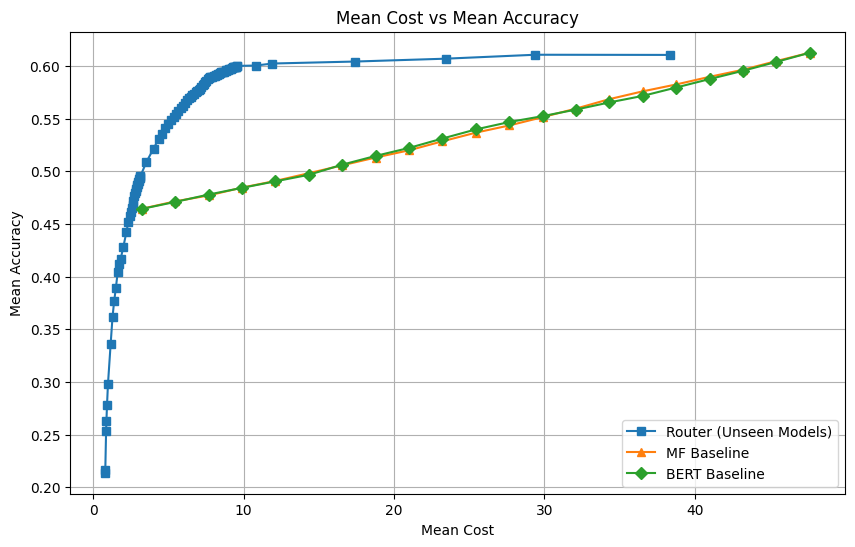

In [68]:
plt.figure(figsize=(10, 6))
# plt.plot(costs_ID_seen, accs_ID_seen, marker='o', label="Router (Seen Models)")
plt.plot(costs_ID_unseen, accs_ID_unseen, marker='s', label="Router (Unseen Models)")
plt.plot(mean_cost_MF_baseline, mean_accuracy_MF_baseline, marker='^', label='MF Baseline')
plt.plot(mean_cost_Bert_baseline, mean_accuracy_Bert_baseline, marker='D', label='BERT Baseline')
plt.legend()
plt.xlabel('Mean Cost')
plt.ylabel('Mean Accuracy')
plt.title('Mean Cost vs Mean Accuracy')
plt.grid()
plt.savefig('mean_cost_vs_mean_accuracy_comparison_unseen.png', dpi=300, bbox_inches='tight')
plt.show()

PLOT TO OOD graph (with baselines)

In [69]:
# --- OOD Baselines ---
# Build correct_table for OOD data
correct_raw_ood = (extracted_data.loc[extracted_data['model'].isin([slm, llm]), ["query_id", "model", "correct"]]
                   .drop_duplicates(["query_id", "model"])
                   .pivot(index="query_id", columns="model", values="correct")
                   .reindex(columns=[slm, llm]))
has_table_ood = correct_raw_ood.notna().astype(int)
correct_table_ood = correct_raw_ood.fillna(0)

# BERT baseline for OOD
baseline_scores_bert_ood = pd.read_json('./data/baseline_scores/bert_router_scores_ood.jsonl', lines=True)
pct_ood = np.arange(0, 101, 5)
thresholds_bert_ood = np.percentile(baseline_scores_bert_ood["score"].to_numpy(), pct_ood)

baseline_Bert_ood_df = (baseline_scores_bert_ood[["query_id", "score"]]
    .merge(correct_table_ood, left_on="query_id", right_index=True, how="left")
    .merge(has_table_ood.add_prefix("has_"), left_on="query_id", right_index=True, how="left")
    .fillna(0))

scores_bert_ood = baseline_Bert_ood_df["score"].to_numpy()
slm_col_bert_ood = baseline_Bert_ood_df[slm].to_numpy()
llm_col_bert_ood = baseline_Bert_ood_df[llm].to_numpy()
has_slm_bert_ood = baseline_Bert_ood_df["has_" + slm].to_numpy()
has_llm_bert_ood = baseline_Bert_ood_df["has_" + llm].to_numpy()

mean_accuracy_Bert_ood = []
mean_cost_Bert_ood = []
for t in thresholds_bert_ood:
    use_slm = scores_bert_ood > t
    acc_vec = np.where(use_slm, has_slm_bert_ood * slm_col_bert_ood, has_llm_bert_ood * llm_col_bert_ood)
    mean_accuracy_Bert_ood.append(acc_vec.mean())
    cost_vec = np.where(use_slm, cost_slm * has_slm_bert_ood, cost_llm * has_llm_bert_ood)
    mean_cost_Bert_ood.append(cost_vec.mean())

# MF baseline for OOD
baseline_scores_mf_ood = pd.read_json('./data/baseline_scores/mf_router_scores_ood.jsonl', lines=True)
MF_thresholds_ood = np.percentile(baseline_scores_mf_ood["score"].to_numpy(), pct_ood)

baseline_MF_ood_df = (baseline_scores_mf_ood[["query_id", "score"]]
    .merge(correct_table_ood, left_on="query_id", right_index=True, how="left")
    .merge(has_table_ood.add_prefix("has_"), left_on="query_id", right_index=True, how="left")
    .fillna(0))

scores_mf_ood = baseline_MF_ood_df["score"].to_numpy()
slm_col_mf_ood = baseline_MF_ood_df[slm].to_numpy()
llm_col_mf_ood = baseline_MF_ood_df[llm].to_numpy()
has_slm_mf_ood = baseline_MF_ood_df["has_" + slm].to_numpy()
has_llm_mf_ood = baseline_MF_ood_df["has_" + llm].to_numpy()

mean_accuracy_MF_ood = []
mean_cost_MF_ood = []
for t in MF_thresholds_ood:
    use_slm = scores_mf_ood > t
    acc_vec = np.where(use_slm, has_slm_mf_ood * slm_col_mf_ood, has_llm_mf_ood * llm_col_mf_ood)
    mean_accuracy_MF_ood.append(acc_vec.mean())
    cost_vec = np.where(use_slm, cost_slm * has_slm_mf_ood, cost_llm * has_llm_mf_ood)
    mean_cost_MF_ood.append(cost_vec.mean())

print("OOD baselines computed.")

OOD baselines computed.


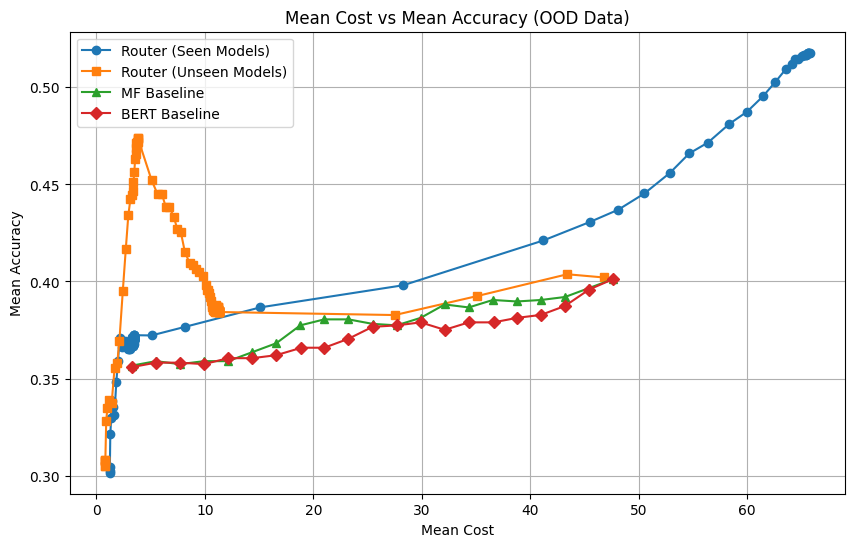

In [70]:
plt.figure(figsize=(10, 6))
plt.plot(costs_OOD_seen, accs_OOD_seen, marker='o', label="Router (Seen Models)")
plt.plot(costs_OOD_unseen, accs_OOD_unseen, marker='s', label="Router (Unseen Models)")
plt.plot(mean_cost_MF_ood, mean_accuracy_MF_ood, marker='^', label='MF Baseline')
plt.plot(mean_cost_Bert_ood, mean_accuracy_Bert_ood, marker='D', label='BERT Baseline')
plt.legend()
plt.xlabel('Mean Cost')
plt.ylabel('Mean Accuracy')
plt.title('Mean Cost vs Mean Accuracy (OOD Data)')
plt.grid()
plt.show()